In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import duckdb
from pathlib import Path
from tqdm import tqdm

In [2]:
clu_params = pd.read_csv("/Users/sharifi/Documents/escapees/data/clu_params.csv")
name = "Platais_8"
dvtlim = 2
distlim = 150
halfedge = 180 / np.sqrt(3)

In [3]:
clu_param = clu_params.loc[clu_params.name == name]
r_clu = clu_param[["x", "y", "z"]].to_numpy().flatten()

bounds = (
    r_clu[0] - halfedge,
    r_clu[0] + halfedge,
    r_clu[1] - halfedge,
    r_clu[1] + halfedge,
    r_clu[2] - halfedge,
    r_clu[2] + halfedge,
)

df_uvw = duckdb.query(f"""
    SELECT * FROM '/Volumes/travelpassport/tables/spheres_with_name/{name}.parquet'
    WHERE dist_from_cluster < {distlim}
    AND parallax_over_error > 10
    AND X >= {bounds[0]}
    AND X <= {bounds[1]}
    AND Y >= {bounds[2]}
    AND Y <= {bounds[3]}
    AND Z >= {bounds[4]}
    AND Z <= {bounds[5]}
""").df()

df_cyl = duckdb.query(f"""
    SELECT * FROM '/Volumes/travelpassport/tables/spheres_cylvel/{name}.parquet'
    WHERE dist_from_cluster < {distlim}
    AND parallax_over_error > 10
    AND X >= {bounds[0]}
    AND X <= {bounds[1]}
    AND Y >= {bounds[2]}
    AND Y <= {bounds[3]}
    AND Z >= {bounds[4]}
    AND Z <= {bounds[5]}

""").df()

df_mom = duckdb.query(f"""
    SELECT * FROM '/Volumes/travelpassport/tables/sample_angmom/{name}.parquet'
    WHERE dist_from_cluster < {distlim}
    AND parallax_over_error > 10
    AND X >= {bounds[0]}
    AND X <= {bounds[1]}
    AND Y >= {bounds[2]}
    AND Y <= {bounds[3]}
    AND Z >= {bounds[4]}
    AND Z <= {bounds[5]}
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

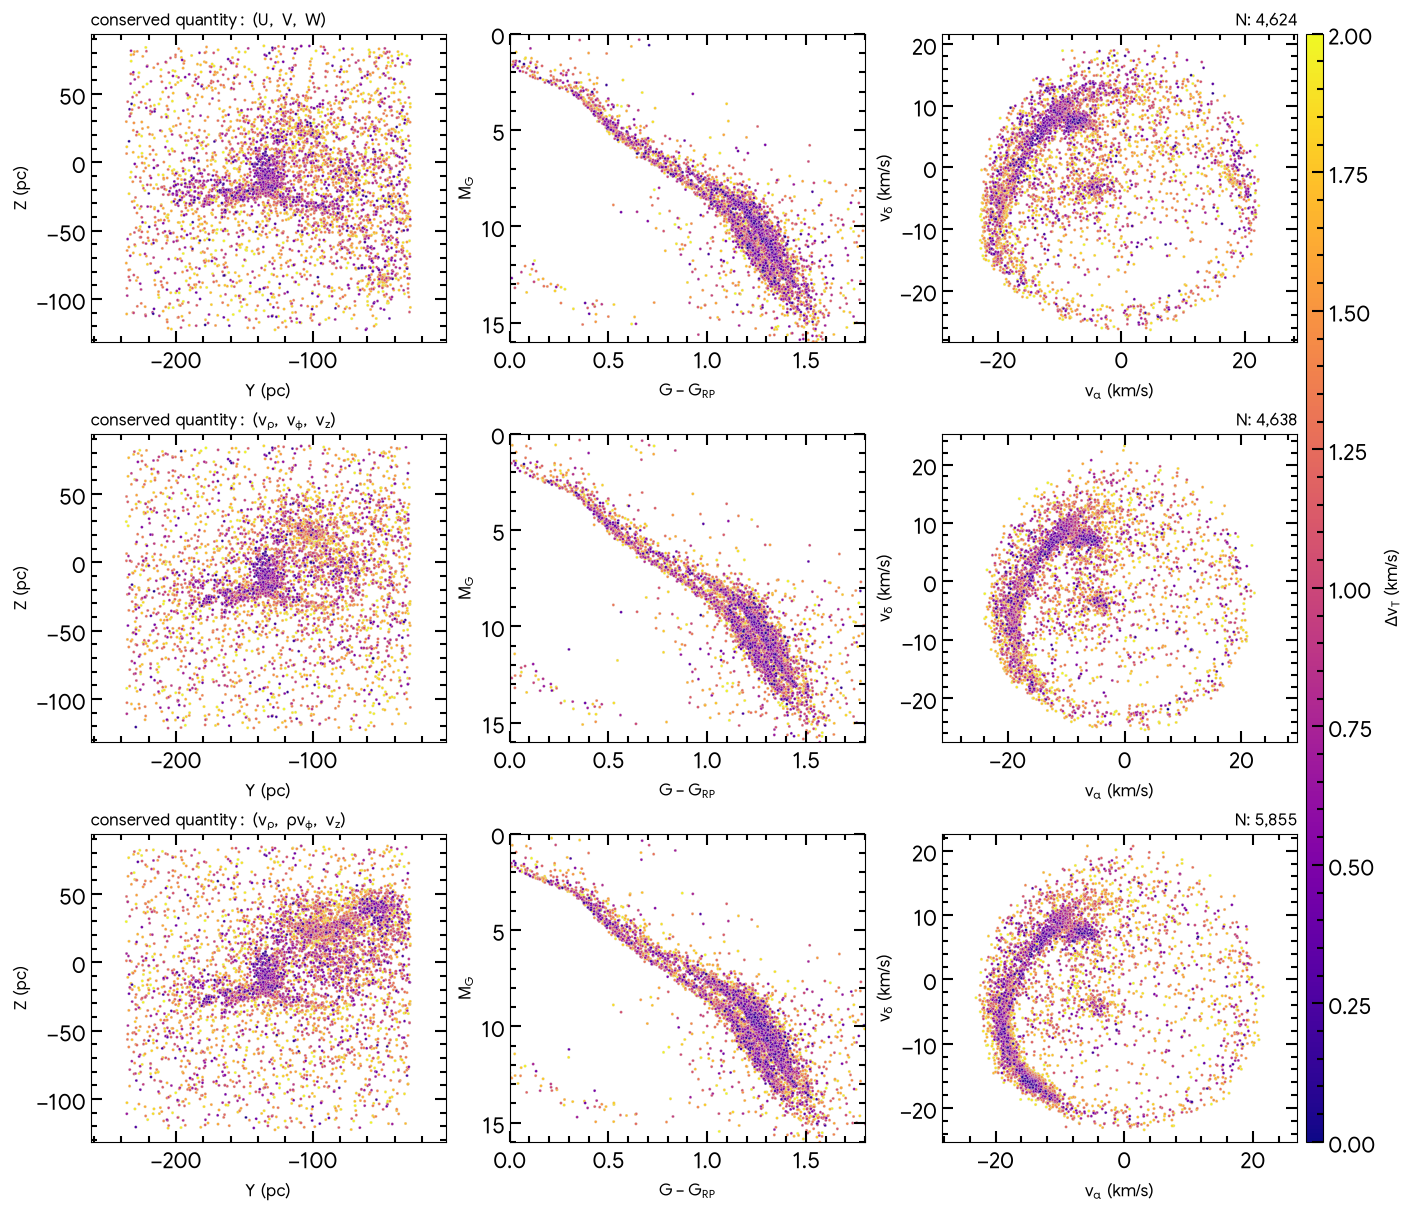

In [5]:
fig = plt.figure(figsize=(14, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 4, width_ratios=[1] * 3 + [0.05])  # last column for colorbar
axes = np.empty((3, 3), dtype=object)
for i in range(3):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

cmap_dvt = cm.plasma
cax = fig.add_subplot(gs[:, -1])
norm_dvt = Normalize(0, dvtlim)
mappable = cm.ScalarMappable(norm=norm_dvt, cmap=cmap_dvt)
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(r"$\Delta v_T\ (km/s)$", fontsize=12)

foo_uvw = df_uvw.loc[df_uvw.delta_vT < dvtlim].copy()
foo_cyl = df_cyl.loc[df_cyl.delta_vT < dvtlim].copy()
foo_mom = df_mom.loc[df_mom.delta_vT < dvtlim].copy()

ix_uvw = np.flip(np.argsort(foo_uvw["delta_vT"]))
ix_cyl = np.flip(np.argsort(foo_cyl["delta_vT"]))
ix_mom = np.flip(np.argsort(foo_mom["delta_vT"]))

foo_cyl = foo_cyl.iloc[ix_cyl]
foo_uvw = foo_uvw.iloc[ix_uvw]
foo_mom = foo_mom.iloc[ix_mom]

axes[0, 0].scatter(
    foo_uvw["Y"],
    foo_uvw["Z"],
    c=foo_uvw["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[0, 1].scatter(
    foo_uvw["g_rp"],
    foo_uvw["phot_g_mean_mag"] + 5 * np.log10(foo_uvw.parallax / 100),
    c=foo_uvw["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[0, 2].scatter(
    foo_uvw["vra"],
    foo_uvw["vdec"],
    c=foo_uvw["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[1, 0].scatter(
    foo_cyl["Y"],
    foo_cyl["Z"],
    c=foo_cyl["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[1, 1].scatter(
    foo_cyl["g_rp"],
    foo_cyl["phot_g_mean_mag"] + 5 * np.log10(foo_cyl.parallax / 100),
    c=foo_cyl["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[1, 2].scatter(
    foo_cyl["vra"],
    foo_cyl["vdec"],
    c=foo_cyl["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[2, 0].scatter(
    foo_mom["Y"],
    foo_mom["Z"],
    c=foo_mom["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[2, 1].scatter(
    foo_mom["g_rp"],
    foo_mom["phot_g_mean_mag"] + 5 * np.log10(foo_mom.parallax / 100),
    c=foo_mom["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[2, 2].scatter(
    foo_mom["vra"],
    foo_mom["vdec"],
    c=foo_mom["delta_vT"],
    cmap=cmap_dvt,
    norm=norm_dvt,
    s=4,
    edgecolors="gainsboro",
    linewidth=0.2,
)

axes[0, 0].set_title(r"$conserved\ quantity:\ (U,\ V,\ W)$", fontsize=12, loc="left")

axes[1, 0].set_title(
    r"$conserved\ quantity:\ (v_\rho,\ v_\phi,\ v_z)$", fontsize=12, loc="left"
)

axes[2, 0].set_title(
    r"$conserved\ quantity:\ (v_\rho,\ \rho v_\phi,\ v_z)$", fontsize=12, loc="left"
)

axes[0, 2].set_title(f"N: {len(foo_uvw):,}", fontsize=12, loc="right")

axes[1, 2].set_title(f"N: {len(foo_cyl):,}", fontsize=12, loc="right")

axes[2, 2].set_title(f"N: {len(foo_mom):,}", fontsize=12, loc="right")

for ax in axes[:, 0]:
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel(r"$Y\ (pc)$", fontsize=12)
    ax.set_ylabel(r"$Z\ (pc)$", fontsize=12)

for ax in axes[:, 1]:
    ax.set_xlabel(r"$G-G_{RP}$", fontsize=12)
    ax.set_ylabel(r"$M_G$", fontsize=12)
    ax.set_xlim(0, 1.8)
    ax.set_ylim(0, 16)
    ax.invert_yaxis()

for ax in axes[:, 2]:
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel(r"$v_\alpha\ (km/s)$", fontsize=12)
    ax.set_ylabel(r"$v_\delta\ (km/s)$", fontsize=12)

# plt.savefig(
#     f"/Volumes/travelpassport/method_comparison_plots/{name}.png",
#     dpi=400,
#     bbox_inches="tight",
# )
plt.show()

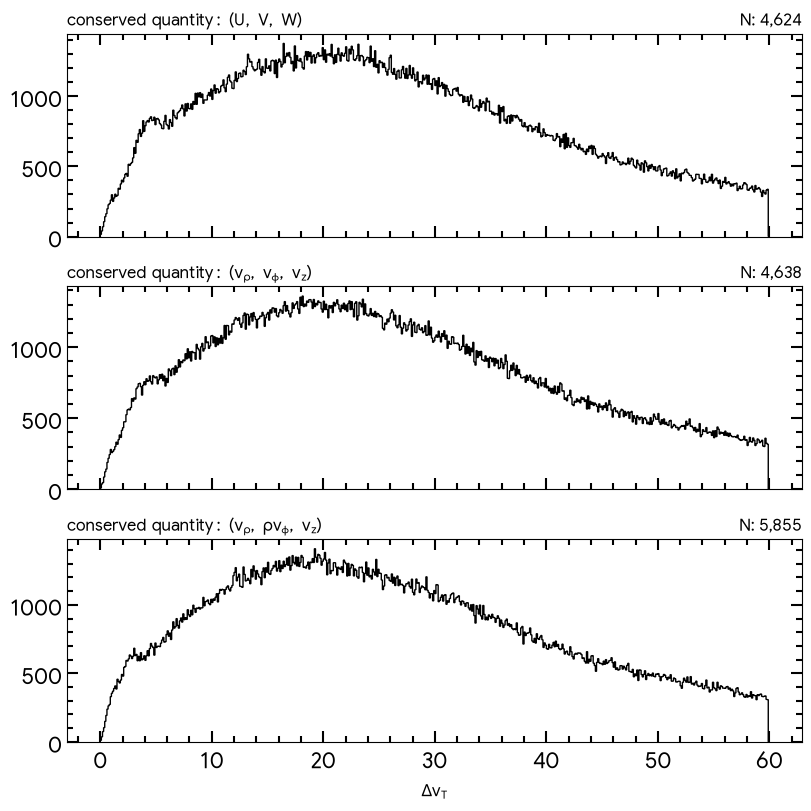

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), constrained_layout=True, sharex=True)

axes[0].hist(df_uvw["delta_vT"], bins=np.arange(0, 60, 0.1), color="k", histtype="step")
axes[1].hist(df_cyl["delta_vT"], bins=np.arange(0, 60, 0.1), color="k", histtype="step")
axes[2].hist(df_mom["delta_vT"], bins=np.arange(0, 60, 0.1), color="k", histtype="step")


axes[0].set_title(r"$conserved\ quantity:\ (U,\ V,\ W)$", fontsize=12, loc="left")

axes[1].set_title(
    r"$conserved\ quantity:\ (v_\rho,\ v_\phi,\ v_z)$", fontsize=12, loc="left"
)

axes[2].set_title(
    r"$conserved\ quantity:\ (v_\rho,\ \rho v_\phi,\ v_z)$", fontsize=12, loc="left"
)

axes[0].set_title(f"N: {len(foo_uvw):,}", fontsize=12, loc="right")

axes[1].set_title(f"N: {len(foo_cyl):,}", fontsize=12, loc="right")

axes[2].set_title(f"N: {len(foo_mom):,}", fontsize=12, loc="right")

axes[2].set_xlabel(r"$\Delta v_T$", fontsize=12)

plt.show()